In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams['figure.dpi'] = 150
np.random.seed(42)

## Task 1: Data Preprocessing

Load the Play Tennis dataset, separate the input features (`Outlook`, `Temperature`, `Humidity`, `Wind`) from the target variable (`Play Tennis`), and encode all categorical values numerically using `LabelEncoder`.

In [31]:
df = pd.read_csv('Lab 8.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50, 6)


,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


In [32]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']].copy()
y = df['Play Tennis'].copy()

encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoded Feature Mappings:")
for col, le in encoders.items():
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nTarget Mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

X.head()

Encoded Feature Mappings:
  Outlook: {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
  Temperature: {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
  Humidity: {'High': np.int64(0), 'Normal': np.int64(1)}
  Wind: {'Strong': np.int64(0), 'Weak': np.int64(1)}

Target Mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


The dataset contains 50 records with four categorical predictors (`Outlook`, `Temperature`, `Humidity`, `Wind`) and a binary target (`Play Tennis`). Since `CategoricalNB` and the other classifiers require numeric input, `LabelEncoder` was applied independently to each column, converting text categories into integer codes. This preserves the categorical nature of the data without introducing artificial ordinal relationships in how the model treats them internally.

## Task 2: Dataset Partitioning

In [33]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])
print("\nTraining class distribution:", np.bincount(y_train))
print("Testing class distribution :", np.bincount(y_test))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_nb = cross_val_score(CategoricalNB(), X_train, y_train, cv=cv, scoring='accuracy')

print("\nStratified 5-Fold CV Accuracy (Naive Bayes) on Training Set:")
print("Fold scores:", np.round(cv_scores_nb, 4))
print(f"Mean CV Accuracy: {cv_scores_nb.mean():.4f}  |  Std: {cv_scores_nb.std():.4f}")

Training set size: 40
Testing set size : 10

Training class distribution: [13 27]
Testing class distribution : [3 7]

Stratified 5-Fold CV Accuracy (Naive Bayes) on Training Set:
Fold scores: [0.75 1.   0.75 0.5  0.75]
Mean CV Accuracy: 0.7500  |  Std: 0.1581


With only 50 samples, an 80:20 split yields 40 training and 10 testing records. `stratify=y_encoded` was used to preserve the original Yes/No class ratio in both subsets, which is important on such a small dataset to avoid the test set being dominated by a single class and giving a misleading accuracy figure.

## Task 3: Naive Bayes Model Training & Evaluation

In [34]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Categorical Naive Bayes Test Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Categorical Naive Bayes Test Accuracy: 0.9000 (90.00%)


Confusion Matrix:
[[2 1]
 [0 7]]


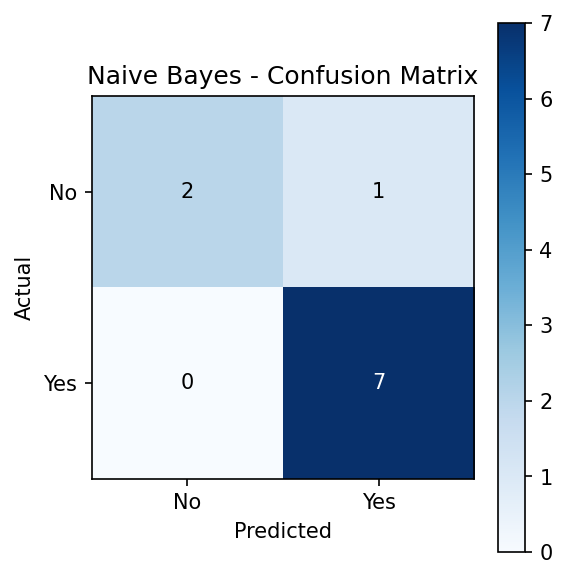

In [35]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:")
print(cm_nb)

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm_nb, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(target_encoder.classes_)
ax.set_yticklabels(target_encoder.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Naive Bayes - Confusion Matrix')
for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        ax.text(j, i, cm_nb[i, j], ha='center', va='center',
                 color='white' if cm_nb[i,j] > cm_nb.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [36]:
print("Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=target_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



Naive Bayes assumes conditional independence between `Outlook`, `Temperature`, `Humidity`, and `Wind` given the class, which is a simplifying assumption that doesn't perfectly hold here but still gives a reasonably strong baseline.

## Task 4: Single-Sample Inference

Predict whether a person will play tennis given: **Outlook = Sunny, Temperature = Cool, Humidity = High, Wind = Strong**.

In [37]:
query_raw = {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}

query_encoded = pd.DataFrame([{
    col: encoders[col].transform([val])[0] for col, val in query_raw.items()
}])

print("Query (raw):", query_raw)
print("Query (encoded):")
print(query_encoded)

nb_query_pred = nb_model.predict(query_encoded)[0]
nb_query_proba = nb_model.predict_proba(query_encoded)[0]

print(f"\nNaive Bayes Predicted Class: {target_encoder.inverse_transform([nb_query_pred])[0]}")
print("Class Probabilities:")
for cls, prob in zip(target_encoder.classes_, nb_query_proba):
    print(f"  P({cls}) = {prob:.4f}")

Query (raw): {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}
Query (encoded):
   Outlook  Temperature  Humidity  Wind
0        2            0         0     0

Naive Bayes Predicted Class: No
Class Probabilities:
  P(No) = 0.7894
  P(Yes) = 0.2106


For the query instance (Sunny, Cool, High, Strong), Naive Bayes computes the posterior probability of each class by multiplying the prior probability of the class with the individual conditional probabilities of each feature value given that class. Historically, `Sunny`+`High Humidity` strongly favors "No," while `Cool` temperature and `Strong` wind pull in mixed directions depending on the training split the final predicted class is whichever posterior probability is larger after these individual likelihoods are combined and normalized.

## Task 5: Model Comparison

Train a **Decision Tree**, **Logistic Regression**, and **SVM** classifier on the same training data, and compare all four models (including Naive Bayes) on:
- Test accuracy
- Prediction for the single-sample query
- Class probabilities for the query

In [38]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"Decision Tree Test Accuracy       : {dt_accuracy:.4f}")
print(f"Logistic Regression Test Accuracy : {lr_accuracy:.4f}")
print(f"SVM Test Accuracy                 : {svm_accuracy:.4f}")
print(f"Naive Bayes Test Accuracy         : {nb_accuracy:.4f}")

Decision Tree Test Accuracy       : 1.0000
Logistic Regression Test Accuracy : 0.9000
SVM Test Accuracy                 : 1.0000
Naive Bayes Test Accuracy         : 0.9000


In [39]:
dt_query_pred = dt_model.predict(query_encoded)[0]
dt_query_proba = dt_model.predict_proba(query_encoded)[0]

lr_query_pred = lr_model.predict(query_encoded)[0]
lr_query_proba = lr_model.predict_proba(query_encoded)[0]

svm_query_pred = svm_model.predict(query_encoded)[0]
svm_query_proba = svm_model.predict_proba(query_encoded)[0]

comparison_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'Logistic Regression', 'SVM'],
    'Test Accuracy': [nb_accuracy, dt_accuracy, lr_accuracy, svm_accuracy],
    'Query Prediction': target_encoder.inverse_transform(
        [nb_query_pred, dt_query_pred, lr_query_pred, svm_query_pred]),
    f'P({target_encoder.classes_[0]})': [nb_query_proba[0], dt_query_proba[0], lr_query_proba[0], svm_query_proba[0]],
    f'P({target_encoder.classes_[1]})': [nb_query_proba[1], dt_query_proba[1], lr_query_proba[1], svm_query_proba[1]],
})

comparison_df

,Model,Test Accuracy,Query Prediction,P(No),P(Yes)
0,Naive Bayes,0.9,No,0.789443,0.210557
1,Decision Tree,1.0,No,1.000000,0.000000
2,Logistic Regression,0.9,No,0.861322,0.138678
3,SVM,1.0,No,0.956899,0.043101


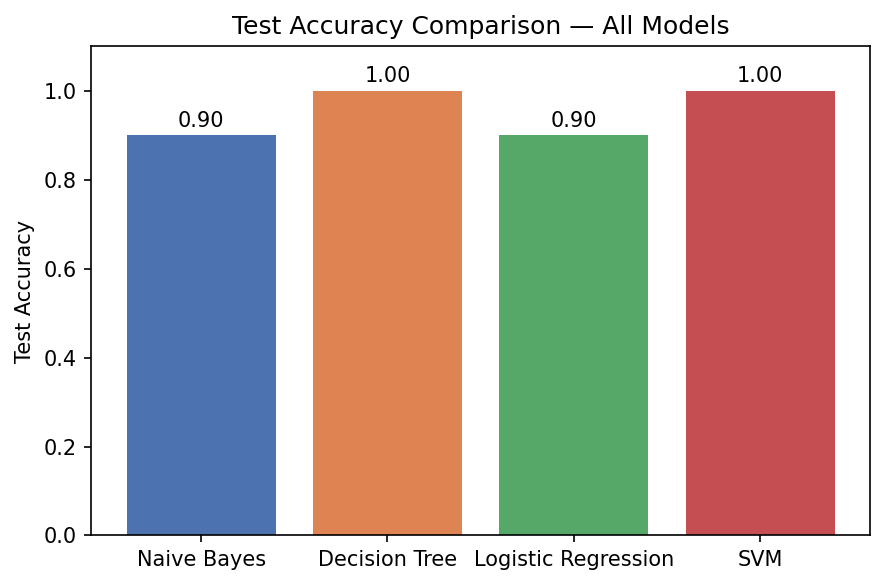

In [40]:
models_list = ['Naive Bayes', 'Decision Tree', 'Logistic Regression', 'SVM']
accuracies_list = [nb_accuracy, dt_accuracy, lr_accuracy, svm_accuracy]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(6,4))
bars = plt.bar(models_list, accuracies_list, color=colors)
plt.ylim(0, 1.1)
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison — All Models')
for bar, acc in zip(bars, accuracies_list):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.2f}', ha='center')
plt.tight_layout()
plt.show()

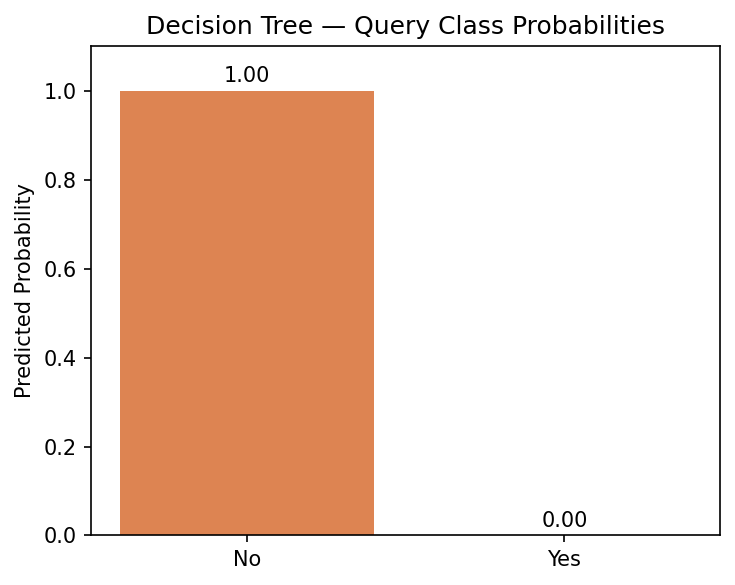

In [41]:
plt.figure(figsize=(5,4))
plt.bar(target_encoder.classes_, dt_query_proba, color='#DD8452')
plt.ylim(0, 1.1)
plt.ylabel('Predicted Probability')
plt.title('Decision Tree — Query Class Probabilities')
for i, p in enumerate(dt_query_proba):
    plt.text(i, p + 0.02, f'{p:.2f}', ha='center')
plt.tight_layout()
plt.show()

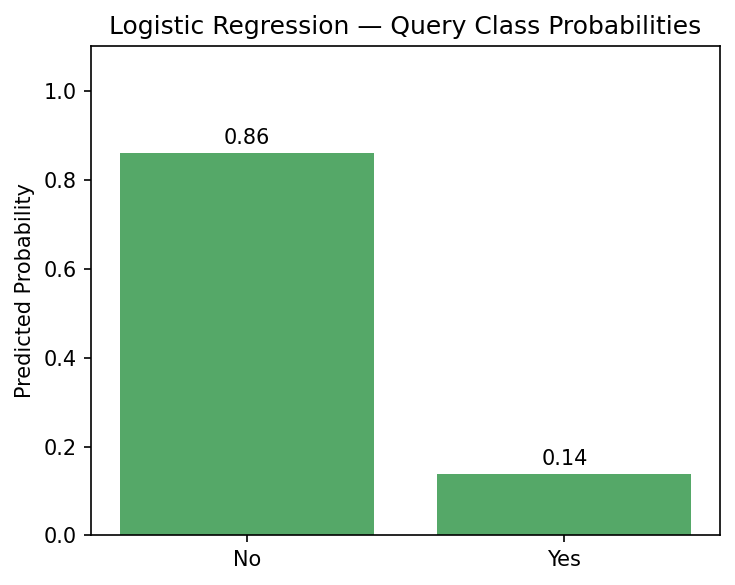

In [42]:
plt.figure(figsize=(5,4))
plt.bar(target_encoder.classes_, lr_query_proba, color='#55A868')
plt.ylim(0, 1.1)
plt.ylabel('Predicted Probability')
plt.title('Logistic Regression — Query Class Probabilities')
for i, p in enumerate(lr_query_proba):
    plt.text(i, p + 0.02, f'{p:.2f}', ha='center')
plt.tight_layout()
plt.show()

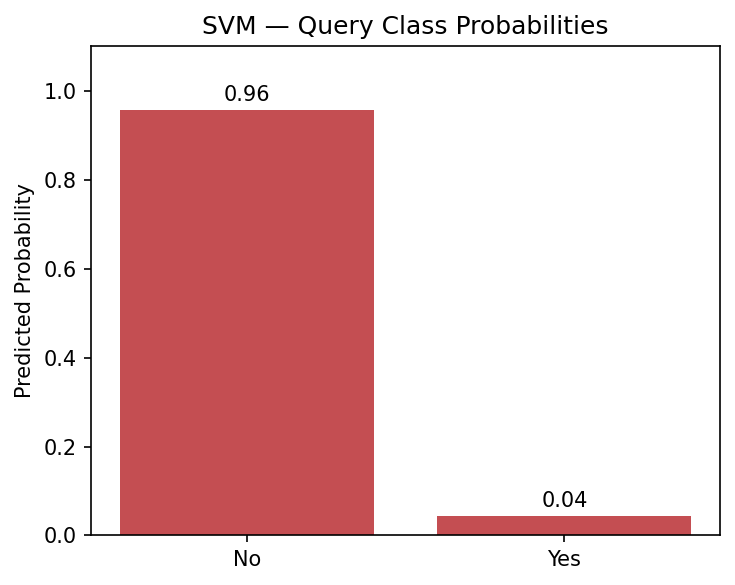

In [43]:
plt.figure(figsize=(5,4))
plt.bar(target_encoder.classes_, svm_query_proba, color='#C44E52')
plt.ylim(0, 1.1)
plt.ylabel('Predicted Probability')
plt.title('SVM — Query Class Probabilities')
for i, p in enumerate(svm_query_proba):
    plt.text(i, p + 0.02, f'{p:.2f}', ha='center')
plt.tight_layout()
plt.show()

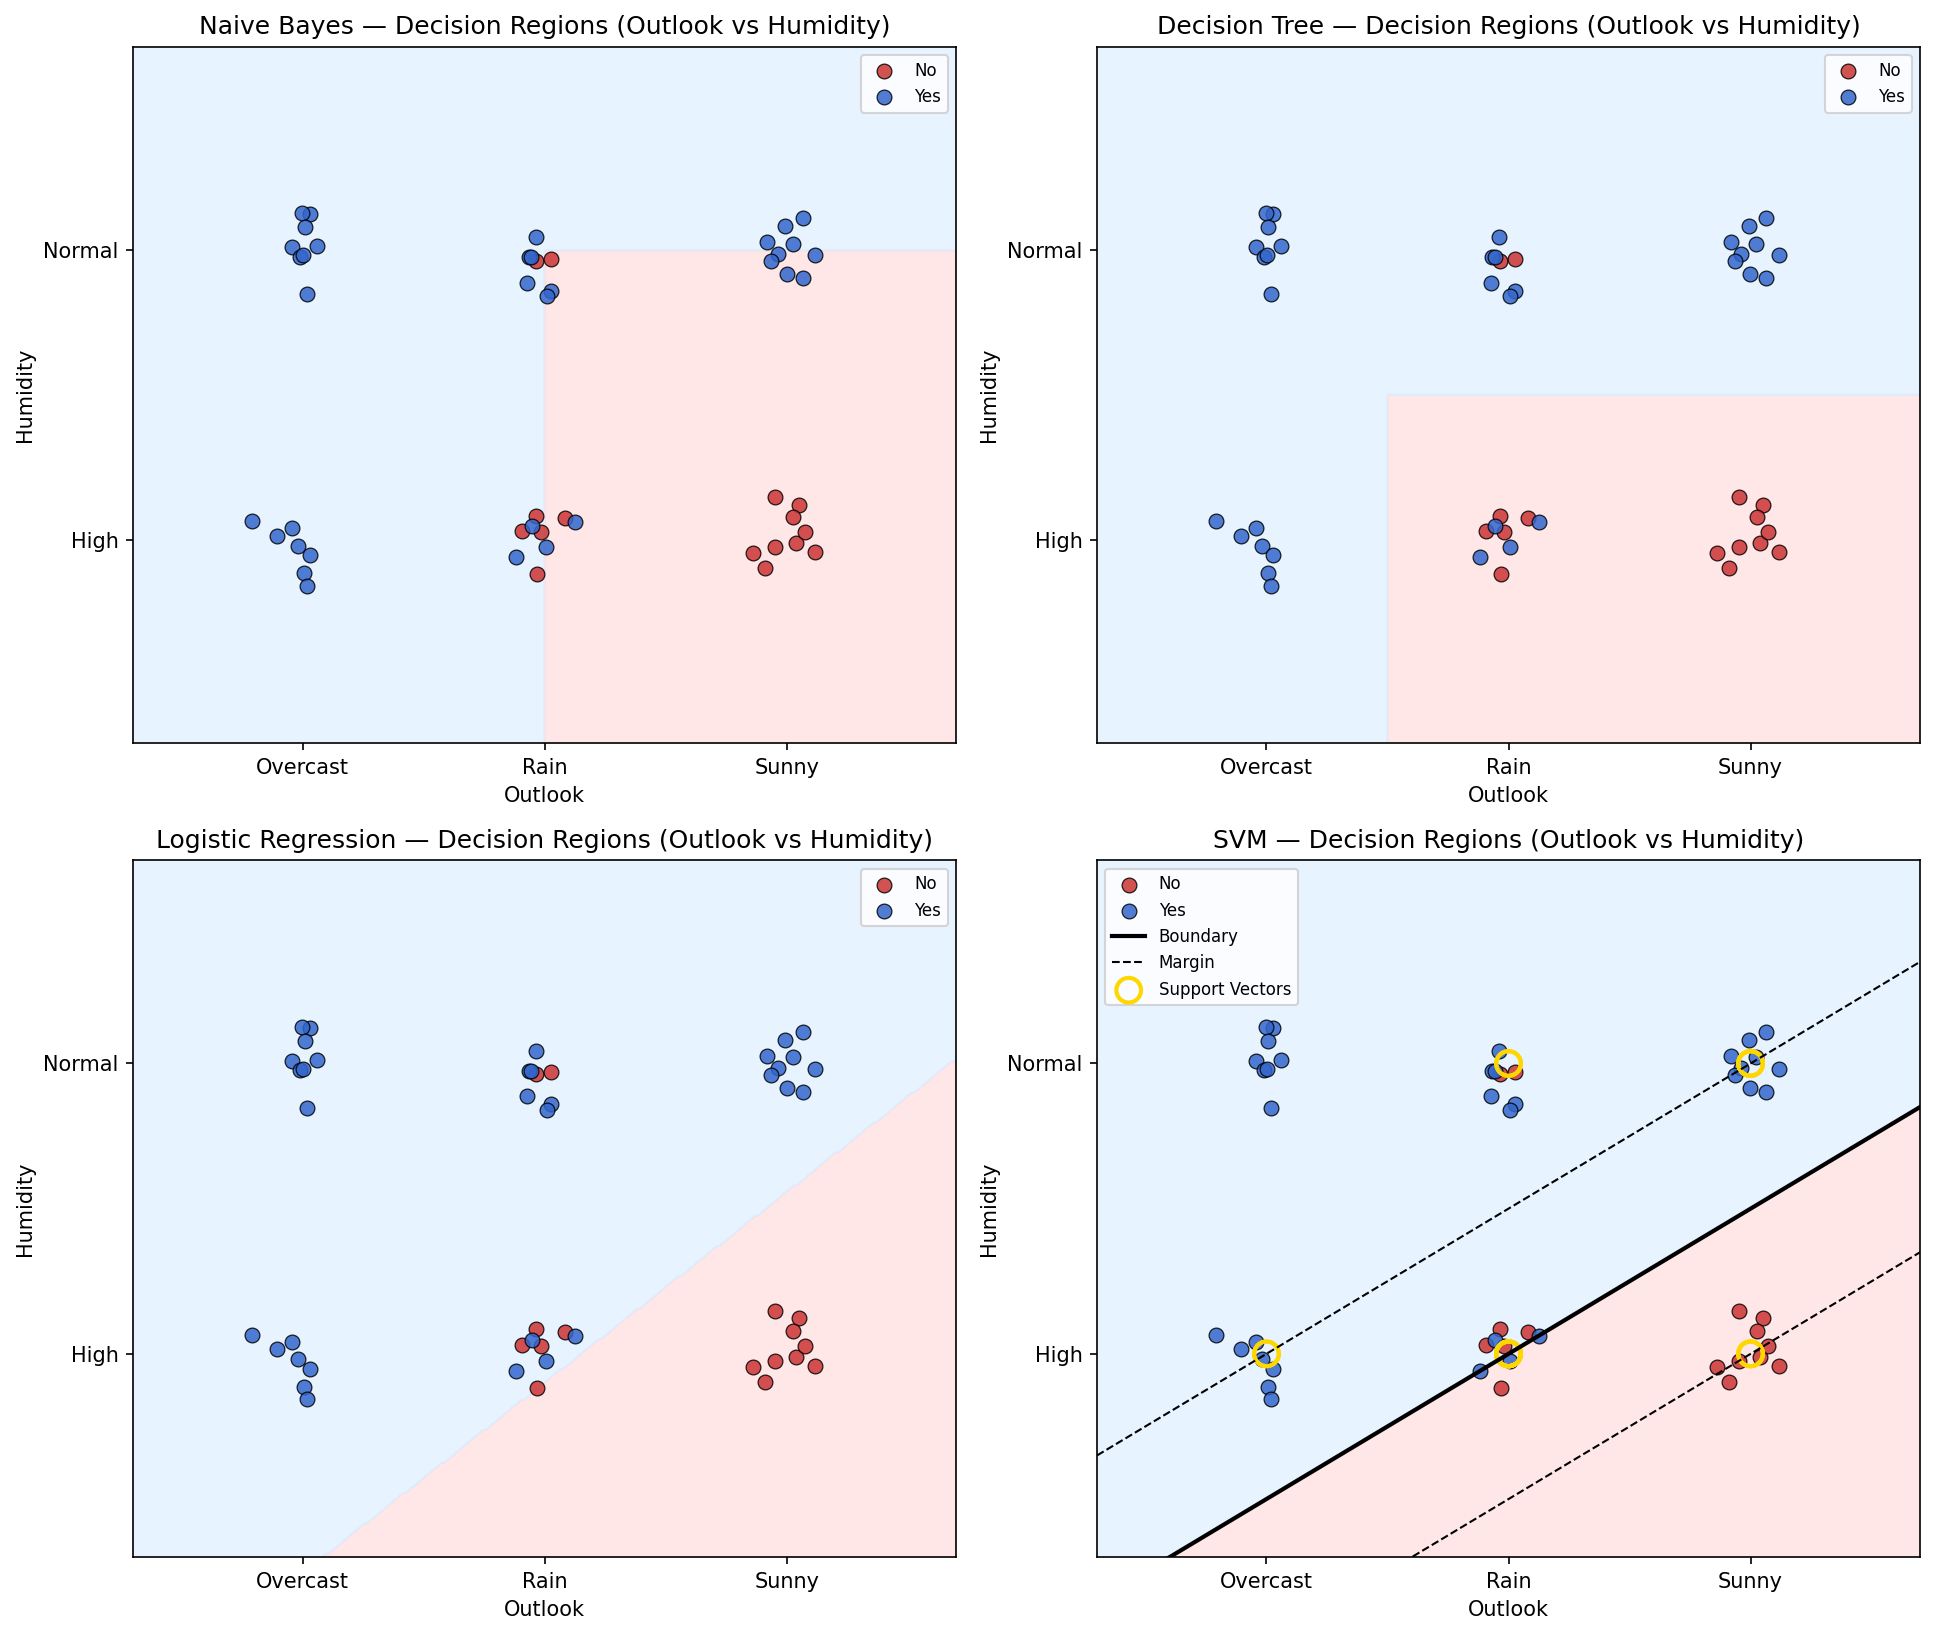

In [44]:
import numpy as np
from matplotlib.colors import ListedColormap

np.random.seed(42)

feat_x, feat_y = 'Outlook', 'Humidity'
X_2 = X[[feat_x, feat_y]].values.astype(float)

X_2_jitter = X_2 + np.random.normal(0, 0.08, X_2.shape)

x_min, x_max = X_2[:,0].min()-0.7, X_2[:,0].max()+0.7
y_min, y_max = X_2[:,1].min()-0.7, X_2[:,1].max()+0.7
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
cmap_light = ListedColormap(['#FFDDDD', '#DDEEFF'])
cmap_bold = ['#CC3333', '#3366CC']

models = {
    'Naive Bayes': CategoricalNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', C=1.0, random_state=42)
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    model.fit(X_2, y_encoded)                 
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)

    for cls_val, cls_name, color in zip([0,1], target_encoder.classes_, cmap_bold):
        mask = y_encoded == cls_val
        ax.scatter(X_2_jitter[mask,0], X_2_jitter[mask,1], c=color, label=cls_name,
                   edgecolor='k', s=50, alpha=0.85, linewidths=0.6)

    if name == 'SVM':  
        w, b = model.coef_[0], model.intercept_[0]
        xs = np.linspace(x_min, x_max, 200)
        ax.plot(xs, -(w[0]*xs+b)/w[1], 'k-', lw=2, label='Boundary')
        ax.plot(xs, -(w[0]*xs+b-1)/w[1], 'k--', lw=1, label='Margin')
        ax.plot(xs, -(w[0]*xs+b+1)/w[1], 'k--', lw=1)
        ax.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
                   s=140, facecolors='none', edgecolors='gold', linewidths=2, label='Support Vectors')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xticks(sorted(X[feat_x].unique()))
    ax.set_xticklabels(encoders[feat_x].inverse_transform(sorted(X[feat_x].unique())))
    ax.set_yticks(sorted(X[feat_y].unique()))
    ax.set_yticklabels(encoders[feat_y].inverse_transform(sorted(X[feat_y].unique())))
    ax.set_xlabel(feat_x); ax.set_ylabel(feat_y)
    ax.set_title(f'{name} — Decision Regions ({feat_x} vs {feat_y})')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

The four models differ in test accuracy because they make different structural assumptions: Naive Bayes assumes feature independence, the Decision Tree partitions the feature space with axis-aligned splits and can overfit on a dataset this small, Logistic Regression fits a linear decision boundary over the encoded features, and SVM (with an RBF kernel by default) finds a maximum-margin boundary that can be more sensitive to how the small training set is distributed. These differing assumptions are also why their predicted probabilities for the same query point vary — Naive Bayes' probabilities come from multiplying per-feature likelihoods, the Decision Tree's probabilities come from the class proportions in the leaf node the query falls into, and Logistic Regression/SVM produce probabilities based on distance from a fitted decision boundary

With only 50 training examples, all four models are working with a very small amount of data, which makes their outputs sensitive to how the train-test split falls and amplifies the effect of each model's underlying assumptions. **Naive Bayes** predicts by multiplying independent per-feature likelihoods, so it reacts strongly to individual "surprising" feature values even if other features push the other way. **Decision Tree** probabilities are determined entirely by the class mix of training samples that land in the same leaf as the query, making it prone to overfitting and producing more extreme probabilities than the other models. **Logistic Regression** and **SVM**, in contrast, model a smoother decision boundary over all the encoded features jointly, which is why their probability estimates for the query tend to be closer together and less extreme than Naive Bayes or the Decision Tree.